---
date: "2026-07-28"
date-modified: last-modified
format:
  html:
    toc: true
---


# Autocorrelation and Stationarity

## 1\. Stationarity

In time series analysis, we often assume that the underlying probability distribution of the data is invariant over time. Without some form of stationarity, we would not be able to use historical data to make inferences about the future, because each time point would have its own unique distribution that we cannot estimate with only one observation per point.

There are two main definitions of stationarity:

::: {#def-strict-stationarity}
## Strict Stationarity
A time series $\{r_t\}$ is strictly stationary if the joint distribution of $(r_{t_1}, r_{t_2}, \dots, r_{t_k})$ is identical to the joint distribution of $(r_{t_1+t}, r_{t_2+t}, \dots, r_{t_k+t})$ for all $t$, where $k$ is an arbitrary positive integer and $(t_1, \dots, t_k)$ is a collection of arbitrary positive integers.
:::

Because strict stationarity is very difficult to verify empirically, we often rely on a weaker form.

::: {#def-weak-stationarity}
## Weak Stationarity
A time series $\{r_t\}$ is weakly stationary if both its mean and the covariance between $r_t$ and $r_{t-\ell}$ do not depend on the time $t$, but only on the lag $\ell$. Specifically:

1. $E(r_t) = \mu$, which is a constant.
2. $\text{Cov}(r_t, r_{t-\ell}) = \gamma_\ell$, which depends only on the time lag $\ell$.
:::

::: {.callout-note}
## Intuition: Weak Stationarity
Weak stationarity is much easier to assume computationally. An immediate consequence of weak stationarity (by setting $\ell = 0$) is that the variance is also constant over time: $\text{Var}(r_t) = \text{Cov}(r_t, r_t) = \gamma_0$.
:::

## 2\. Autocovariance and Autocorrelation

To analyze the linear dependence of a stationary series with its past values, we use autocovariance and autocorrelation.

::: {#def-autocovariance}
## Autocovariance
For a weakly stationary time series $\{r_t\}$, the autocovariance function at lag $\ell$ is:
$$
\gamma_\ell = \text{Cov}(r_t, r_{t-\ell}) = E[(r_t - \mu)(r_{t-\ell} - \mu)]
$$
:::

::: {#def-autocorrelation}
## Autocorrelation Function (ACF)
The autocorrelation function at lag $\ell$, denoted $\rho_\ell$, is the correlation coefficient between $r_t$ and $r_{t-\ell}$:
$$
\rho_\ell = \frac{\text{Cov}(r_t, r_{t-\ell})}{\sqrt{\text{Var}(r_t)\text{Var}(r_{t-\ell})}} = \frac{\gamma_\ell}{\gamma_0}
$$
Because it is a correlation coefficient, $\rho_\ell \in [-1, 1]$ and $\rho_0 = 1$.
:::

### 2.1\. Sample Autocorrelation Function

In practice, we estimate the theoretical ACF $\rho_\ell$ using historical data of length $T$.

::: {#def-sample-acf}
## Sample Autocorrelation Function (Sample ACF)
Given a sample $\{r_1, r_2, \dots, r_T\}$ with sample mean $\bar{r}$, the lag-$\ell$ sample autocorrelation $\hat{\rho}_\ell$ is:
$$
\hat{\rho}_\ell = \frac{\sum_{t=\ell+1}^T (r_t - \bar{r})(r_{t-\ell} - \bar{r})}{\sum_{t=1}^T (r_t - \bar{r})^2} \quad \text{for } 0 \le \ell \le T-1
$$
:::

## 3\. White Noise Model

The simplest model for a time series is the white noise model. It serves as a benchmark or a null hypothesis when checking whether a series has any predictable structure (serial correlation).

::: {#def-white-noise}
## White Noise Model
A time series $\{a_t\}$ is a white noise series if the sequence consists of independent and identically distributed (iid) random variables with a finite mean and variance. 
In particular, a strong white noise requires:
- $E[a_t] = 0$
- $\text{Var}(a_t) = \sigma_a^2$
- $\rho_\ell = 0$ for all $\ell > 0$.
:::

If a [return](time-series-returns.ipynb) series $r_t$ follows a white noise model, we can safely conclude there is no linear predictability based on past returns. 




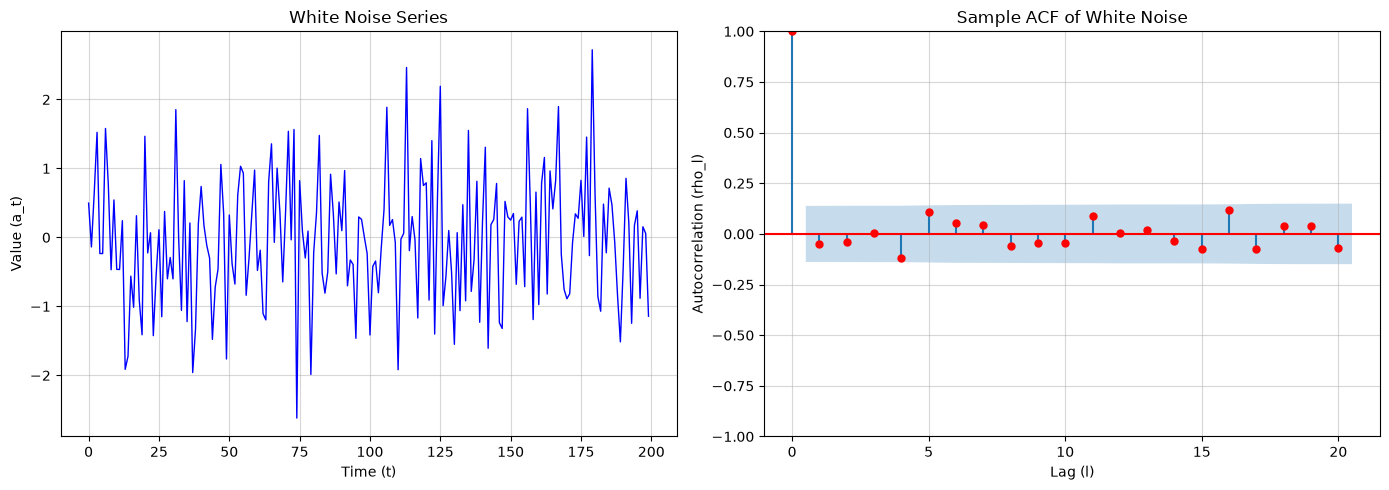

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Set random seed for reproducibility
np.random.seed(42)

# Generate White Noise Data
T = 200
a_t = np.random.normal(0, 1, T)

# Plot White Noise Series and its ACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Time Series
axes[0].plot(a_t, color='blue', linewidth=1)
axes[0].set_title("White Noise Series")
axes[0].set_xlabel("Time (t)")
axes[0].set_ylabel("Value (a_t)")
axes[0].grid(True, alpha=0.5)

# Plot Sample ACF
plot_acf(a_t, ax=axes[1], lags=20, alpha=0.05, color='red')
axes[1].set_title("Sample ACF of White Noise")
axes[1].set_xlabel("Lag (l)")
axes[1].set_ylabel("Autocorrelation (rho_l)")
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


> **References & Acknowledgments:**
> Notes adapted from *Analysis of Financial Time Series*, 2nd/3rd Edition by Ruey S. Tsay.